In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
import os
warnings.filterwarnings('ignore')

# Configuration des visualisations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Configuration pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

In [2]:
def load_cleaned_data():
    """Charge les données nettoyées depuis le fichier pickle"""
    pickle_file = "./data/cleaned/reddit_boycott_combined.pkl"
    if os.path.exists(pickle_file):
        print(f"Chargement des données depuis: {pickle_file}")
        df = pd.read_pickle(pickle_file)
        print(f"Données chargées: {len(df)} posts")
        return df
    else:
        print("Fichier nettoyé non trouvé. Exécutez d'abord la phase de nettoyage.")
        return None

# Charger les données
df = load_cleaned_data()

Chargement des données depuis: ./data/cleaned/reddit_boycott_combined.pkl
Données chargées: 501 posts


In [3]:
# Aperçu rapide
print("="*60)
print("APERÇU INITIAL DES DONNÉES")
print("="*60)
print(f"Shape: {df.shape}")
print(f"\nColonnes disponibles: {list(df.columns)}")
print(f"\nTypes de données:")
print(df.dtypes.head(15))

APERÇU INITIAL DES DONNÉES
Shape: (501, 26)

Colonnes disponibles: ['author_fullname', 'source_file', 'ups', 'score', 'over_18', 'downs', 'permalink', 'num_comments', 'selftext', 'subreddit', 'selftext_length', 'created_utc', 'author', 'link_flair_text', 'total_awards_received', 'downs_calculated', 'created_local_formatted', 'created_local', 'id', 'edited', 'title', 'created_utc_formatted', 'upvote_ratio', 'post_type', 'subreddit_subscribers', 'locked']

Types de données:
author_fullname                  object
source_file                      object
ups                               int64
score                             int64
over_18                            bool
downs                             int64
permalink                        object
num_comments                      int64
selftext                         object
subreddit                        object
selftext_length                 float64
created_utc              datetime64[ns]
author                           object
lin


1. DISTRIBUTION GÉNÉRALE
Distribution par subreddit et type de post:
       subreddit post_type  count  percentage
0            BDS       hot    175        34.9
1            BDS       top    100        20.0
2  BoycottIsrael       hot    125        25.0
3  BoycottIsrael       top    101        20.2



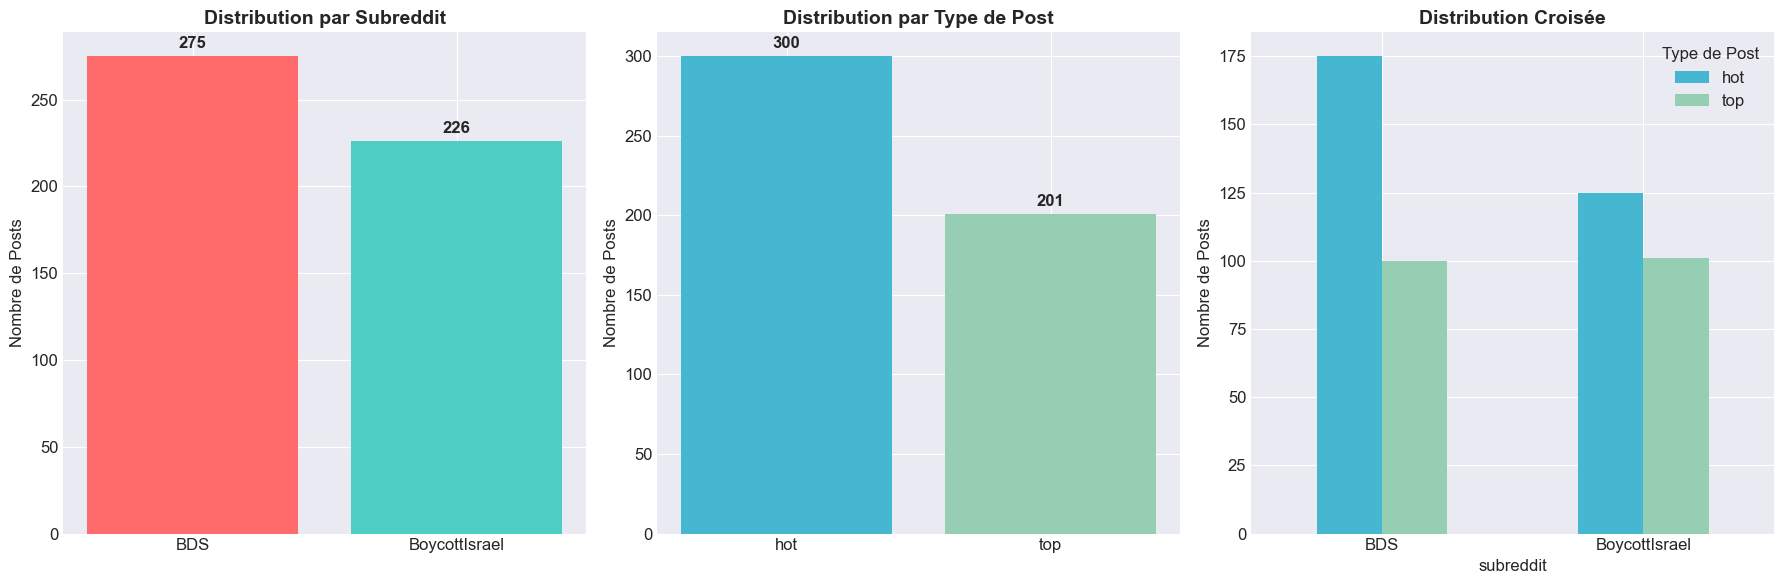

In [4]:
print("\n" + "="*60)
print("1. DISTRIBUTION GÉNÉRALE")
print("="*60)

# Distribution par subreddit et type
dist_table = df.groupby(['subreddit', 'post_type']).size().reset_index(name='count')
dist_table['percentage'] = (dist_table['count'] / len(df) * 100).round(1)
print("Distribution par subreddit et type de post:")
print(dist_table)
print()

# Distribution globale
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Par subreddit
subreddit_counts = df['subreddit'].value_counts()
axes[0].bar(subreddit_counts.index, subreddit_counts.values, color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title('Distribution par Subreddit', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Nombre de Posts')
for i, v in enumerate(subreddit_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 2. Par type de post
post_type_counts = df['post_type'].value_counts()
axes[1].bar(post_type_counts.index, post_type_counts.values, color=['#45B7D1', '#96CEB4'])
axes[1].set_title('Distribution par Type de Post', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Nombre de Posts')
for i, v in enumerate(post_type_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')

# 3. Distribution combinée
cross_counts = df.groupby(['subreddit', 'post_type']).size().unstack(fill_value=0)
cross_counts.plot(kind='bar', ax=axes[2], color=['#45B7D1', '#96CEB4'])
axes[2].set_title('Distribution Croisée', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Nombre de Posts')
axes[2].legend(title='Type de Post')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('./data/cleaned/distribution_general.png', dpi=150, bbox_inches='tight')
plt.show()


2. ANALYSE TEMPORELLE
Période couverte: 2024-05-01 13:10:55 à 2026-01-19 19:45:48
Durée totale: 628 jours

Top 5 mois les plus actifs:
created_month
2026-01    182
2025-12    129
2025-10     31
2025-09     29
2025-06     28
dtype: int64


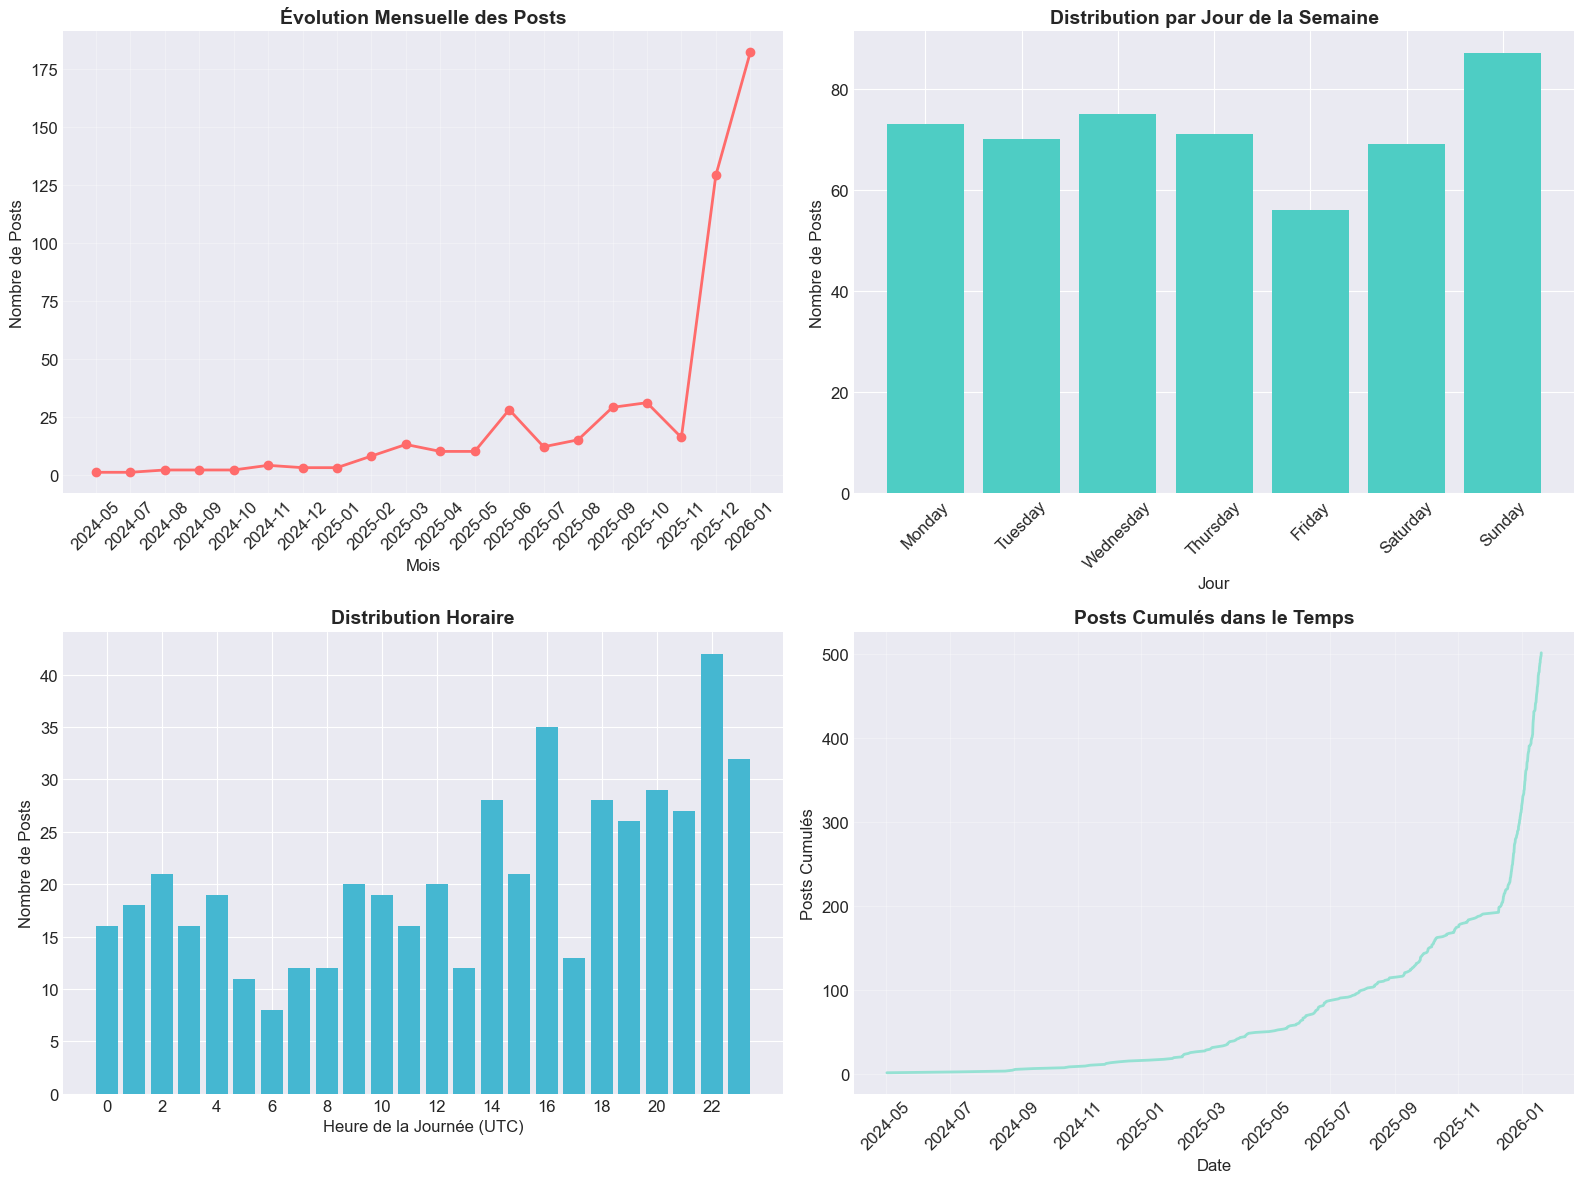

In [5]:
print("\n" + "="*60)
print("2. ANALYSE TEMPORELLE")
print("="*60)

# Préparation des données temporelles
df['created_date'] = df['created_utc'].dt.date
df['created_month'] = df['created_utc'].dt.to_period('M').astype(str)
df['created_week'] = df['created_utc'].dt.isocalendar().year.astype(str) + '-W' + df['created_utc'].dt.isocalendar().week.astype(str).str.zfill(2)
df['created_year_month'] = df['created_utc'].dt.strftime('%Y-%m')
df['day_of_week'] = df['created_utc'].dt.day_name()
df['hour_of_day'] = df['created_utc'].dt.hour

# Statistiques temporelles
print(f"Période couverte: {df['created_utc'].min()} à {df['created_utc'].max()}")
print(f"Durée totale: {(df['created_utc'].max() - df['created_utc'].min()).days} jours")
print()

# Distribution mensuelle
monthly_counts = df.groupby('created_month').size()
print("Top 5 mois les plus actifs:")
print(monthly_counts.sort_values(ascending=False).head())

# Visualisation temporelle
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Évolution mensuelle
monthly_series = df.groupby('created_year_month').size()
axes[0, 0].plot(monthly_series.index, monthly_series.values, marker='o', linewidth=2, color='#FF6B6B')
axes[0, 0].set_title('Évolution Mensuelle des Posts', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Mois')
axes[0, 0].set_ylabel('Nombre de Posts')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribution par jour de la semaine
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['day_of_week'].value_counts().reindex(day_order)
axes[0, 1].bar(day_counts.index, day_counts.values, color='#4ECDC4')
axes[0, 1].set_title('Distribution par Jour de la Semaine', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Jour')
axes[0, 1].set_ylabel('Nombre de Posts')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Distribution horaire
hour_counts = df['hour_of_day'].value_counts().sort_index()
axes[1, 0].bar(hour_counts.index, hour_counts.values, color='#45B7D1')
axes[1, 0].set_title('Distribution Horaire', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Heure de la Journée (UTC)')
axes[1, 0].set_ylabel('Nombre de Posts')
axes[1, 0].set_xticks(range(0, 24, 2))

# 4. Évolution cumulée
df_sorted = df.sort_values('created_utc')
df_sorted['cumulative_posts'] = range(1, len(df_sorted) + 1)
axes[1, 1].plot(df_sorted['created_utc'], df_sorted['cumulative_posts'], linewidth=2, color='#95E1D3')
axes[1, 1].set_title('Posts Cumulés dans le Temps', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Posts Cumulés')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./data/cleaned/analyse_temporelle.png', dpi=150, bbox_inches='tight')
plt.show()


3. ANALYSE PAR AUTEUR
Nombre total d'auteurs uniques: 255
Ratio posts/auteur: 1.96

Statistiques de distribution des posts par auteur:
  - Auteur le plus actif: Tr0jan___ (43 posts)
  - Nombre d'auteurs avec un seul post: 188 (73.7%)
  - Nombre d'auteurs avec 2+ posts: 67 (26.3%)
  - Nombre d'auteurs avec 5+ posts: 16 (6.3%)

Top 10 des auteurs les plus actifs:
                Auteur  Nombre de Posts
0            Tr0jan___               43
1           librephili               28
2            [deleted]               14
3         richards1052               13
4     Able_Compote6571               12
5       ContentChecker               11
6  Practical_Chef_7897               10
7  Financial_Smile4143                8
8           adilbuilds                8
9             Ilovedia                7

Analyse de Pareto (80/20):
  - 155 auteurs produisent 80% des posts (60.8% des auteurs)

Auteurs postant dans les deux subreddits: 19
  90stvkid, Amr_Abu_Ouda, Apollo_Delphi, Firm_Paint8474, Ilo

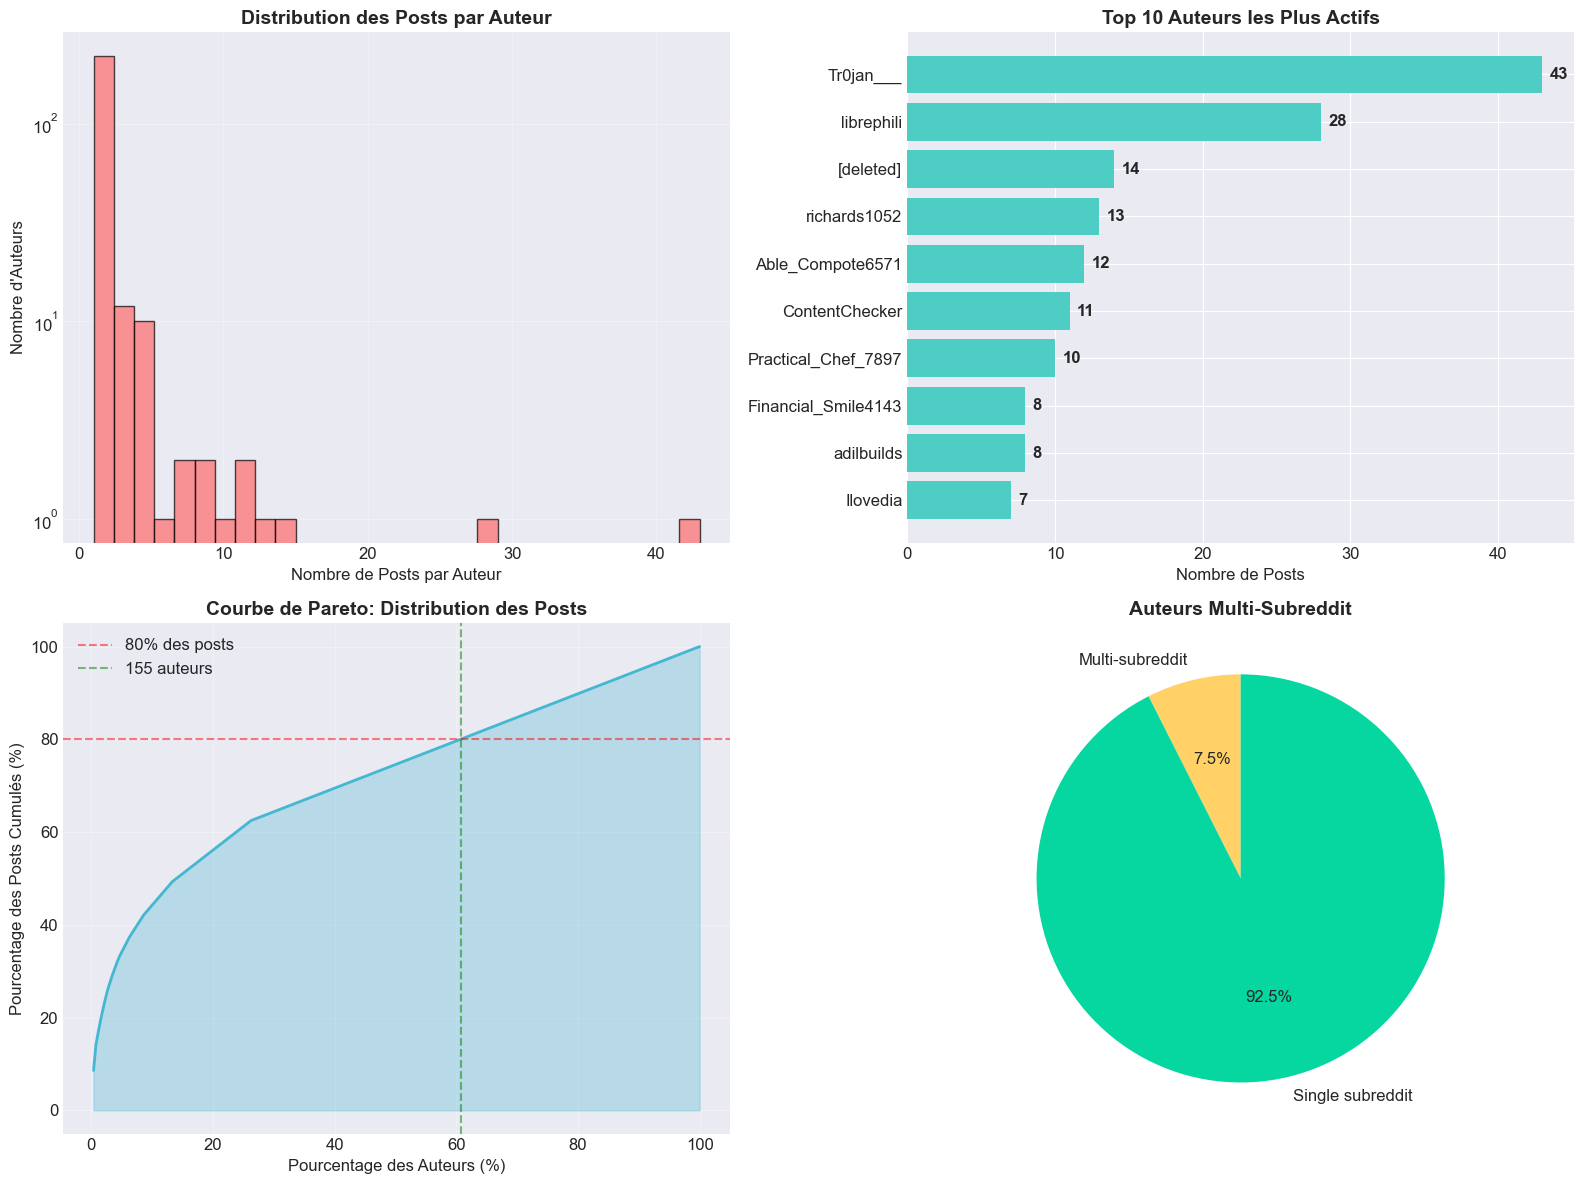

In [6]:
print("\n" + "="*60)
print("3. ANALYSE PAR AUTEUR")
print("="*60)

# Statistiques des auteurs
unique_authors = df['author'].nunique()
print(f"Nombre total d'auteurs uniques: {unique_authors}")
print(f"Ratio posts/auteur: {len(df)/unique_authors:.2f}")
print()

# Distribution des posts par auteur
author_counts = df['author'].value_counts()
print("Statistiques de distribution des posts par auteur:")
print(f"  - Auteur le plus actif: {author_counts.idxmax()} ({author_counts.max()} posts)")
print(f"  - Nombre d'auteurs avec un seul post: {(author_counts == 1).sum()} ({(author_counts == 1).sum()/unique_authors*100:.1f}%)")
print(f"  - Nombre d'auteurs avec 2+ posts: {(author_counts >= 2).sum()} ({(author_counts >= 2).sum()/unique_authors*100:.1f}%)")
print(f"  - Nombre d'auteurs avec 5+ posts: {(author_counts >= 5).sum()} ({(author_counts >= 5).sum()/unique_authors*100:.1f}%)")
print()

# Top 10 auteurs
print("Top 10 des auteurs les plus actifs:")
top_authors = author_counts.head(10).reset_index()
top_authors.columns = ['Auteur', 'Nombre de Posts']
print(top_authors)
print()

# Analyse de la loi de Pareto (80/20)
total_posts = len(df)
cumulative_posts = author_counts.cumsum()
paretto_threshold = total_posts * 0.8
authors_needed = (cumulative_posts <= paretto_threshold).sum() + 1
print(f"Analyse de Pareto (80/20):")
print(f"  - {authors_needed} auteurs produisent 80% des posts ({authors_needed/unique_authors*100:.1f}% des auteurs)")
print()

# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Distribution des posts par auteur (log scale)
axes[0, 0].hist(author_counts.values, bins=30, edgecolor='black', alpha=0.7, color='#FF6B6B')
axes[0, 0].set_title('Distribution des Posts par Auteur', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Nombre de Posts par Auteur')
axes[0, 0].set_ylabel('Nombre d\'Auteurs')
axes[0, 0].set_yscale('log')
axes[0, 0].grid(True, alpha=0.3)

# 2. Top 10 auteurs
top_10 = author_counts.head(10)
bars = axes[0, 1].barh(range(len(top_10)), top_10.values, color='#4ECDC4')
axes[0, 1].set_title('Top 10 Auteurs les Plus Actifs', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Nombre de Posts')
axes[0, 1].set_yticks(range(len(top_10)))
axes[0, 1].set_yticklabels(top_10.index)
axes[0, 1].invert_yaxis()
for i, (bar, count) in enumerate(zip(bars, top_10.values)):
    axes[0, 1].text(count + 0.5, bar.get_y() + bar.get_height()/2, str(count), 
                   va='center', fontweight='bold')

# 3. Analyse de Pareto
sorted_counts = author_counts.sort_values(ascending=False).reset_index(drop=True)
cumulative_percentage = sorted_counts.cumsum() / total_posts * 100
author_percentage = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts) * 100

axes[1, 0].plot(author_percentage, cumulative_percentage, linewidth=2, color='#45B7D1')
axes[1, 0].axhline(y=80, color='r', linestyle='--', alpha=0.5, label='80% des posts')
axes[1, 0].axvline(x=authors_needed/unique_authors*100, color='g', linestyle='--', alpha=0.5, label=f'{authors_needed} auteurs')
axes[1, 0].fill_between(author_percentage, 0, cumulative_percentage, alpha=0.3, color='#45B7D1')
axes[1, 0].set_title('Courbe de Pareto: Distribution des Posts', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Pourcentage des Auteurs (%)')
axes[1, 0].set_ylabel('Pourcentage des Posts Cumulés (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Auteurs cross-subreddit
cross_authors = df.groupby('author')['subreddit'].nunique()
multi_subreddit_authors = cross_authors[cross_authors > 1].index.tolist()
print(f"Auteurs postant dans les deux subreddits: {len(multi_subreddit_authors)}")
if multi_subreddit_authors:
    print("  " + ", ".join(multi_subreddit_authors[:5]) + ("..." if len(multi_subreddit_authors) > 5 else ""))

axes[1, 1].pie([len(multi_subreddit_authors), unique_authors - len(multi_subreddit_authors)],
              labels=['Multi-subreddit', 'Single subreddit'],
              colors=['#FFD166', '#06D6A0'],
              autopct='%1.1f%%',
              startangle=90)
axes[1, 1].set_title('Auteurs Multi-Subreddit', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('./data/cleaned/analyse_auteurs.png', dpi=150, bbox_inches='tight')
plt.show()


4. ANALYSE COMPARATIVE PAR SUBREDDIT
BDS: 275 posts
BoycottIsrael: 226 posts

Comparaison des métriques d'engagement:
       Métrique BDS (moyenne) BoycottIsrael (moyenne) Différence (%) BDS (médiane) BoycottIsrael (médiane)
          score        329.73                  183.42          -44.4        190.00                  185.00
   num_comments         13.56                   11.29          -16.8          7.00                    6.00
   upvote_ratio          0.97                    0.98            0.8          0.99                    0.99
selftext_length        758.66                  488.78          -35.6        408.00                  274.00



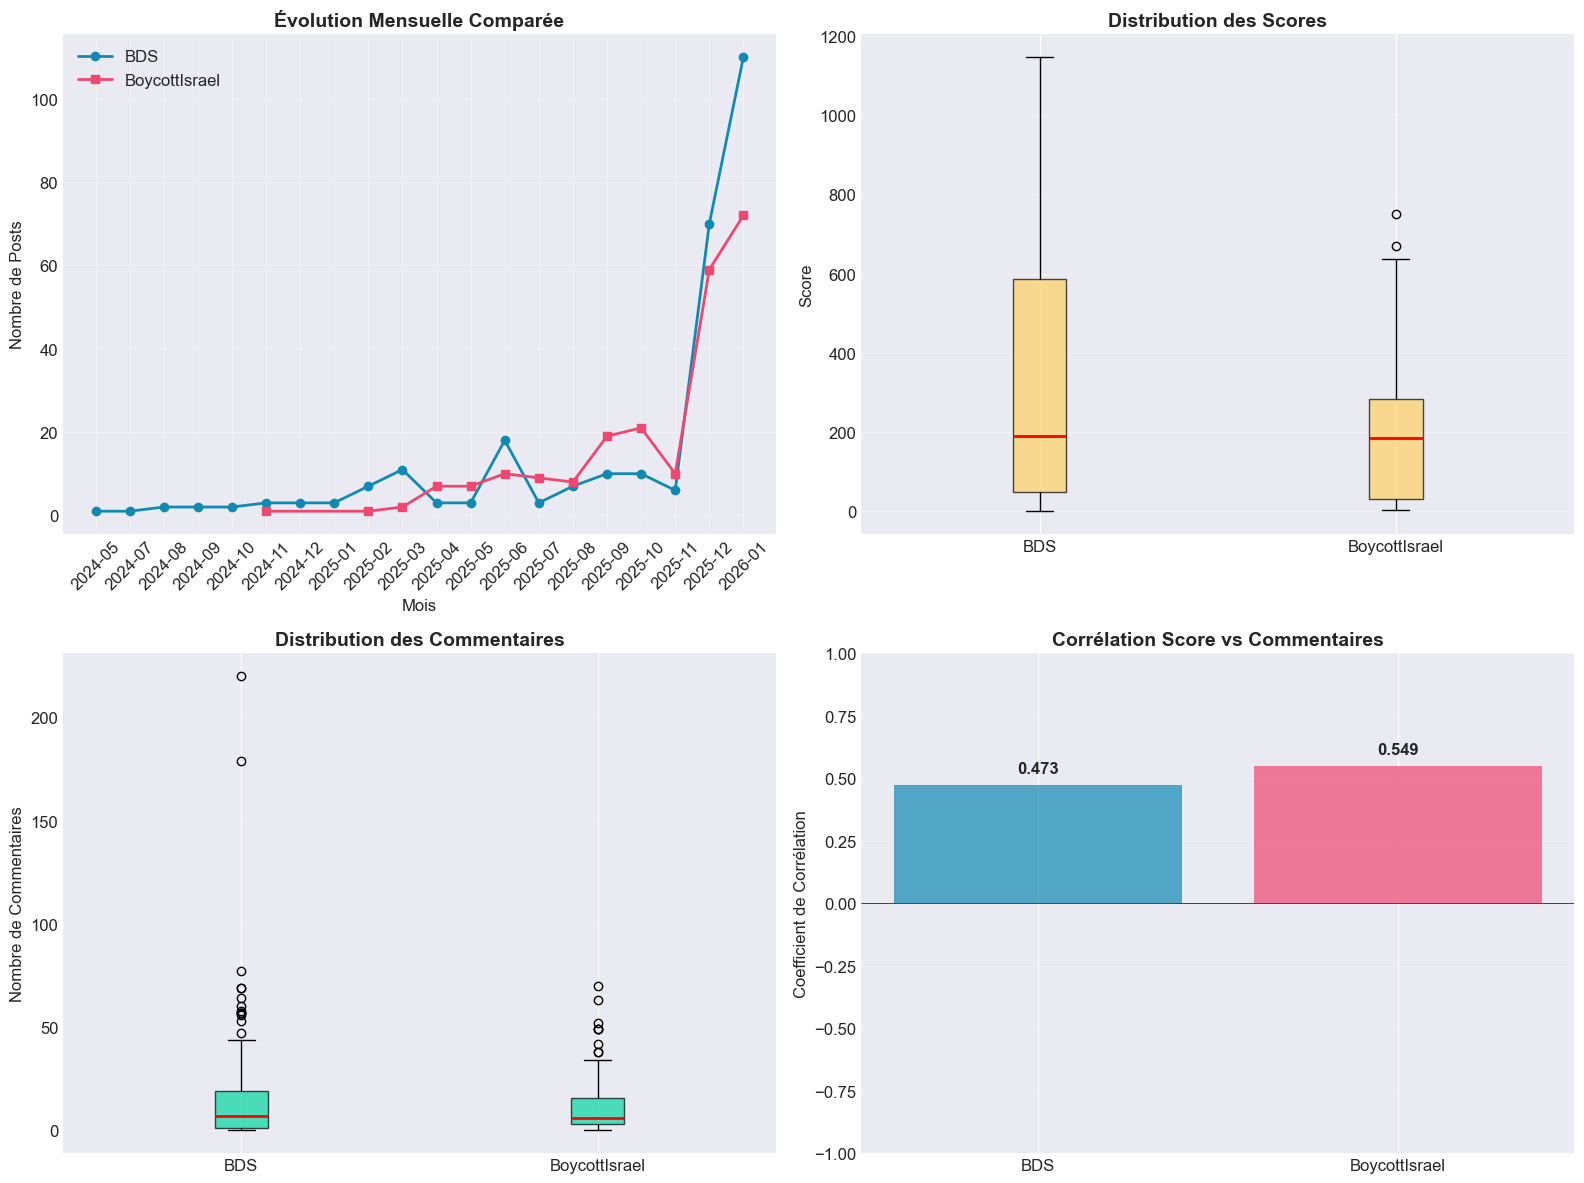

In [7]:
print("\n" + "="*60)
print("4. ANALYSE COMPARATIVE PAR SUBREDDIT")
print("="*60)

# Séparation des données
bds_df = df[df['subreddit'] == 'BDS']
boycott_df = df[df['subreddit'] == 'BoycottIsrael']

print(f"BDS: {len(bds_df)} posts")
print(f"BoycottIsrael: {len(boycott_df)} posts")
print()

# Comparaison des métriques
comparison_metrics = ['score', 'num_comments', 'upvote_ratio', 'selftext_length']
comparison_data = []

for metric in comparison_metrics:
    if metric in df.columns:
        bds_mean = bds_df[metric].mean()
        boycott_mean = boycott_df[metric].mean()
        bds_median = bds_df[metric].median()
        boycott_median = boycott_df[metric].median()
        
        comparison_data.append({
            'Métrique': metric,
            'BDS (moyenne)': f"{bds_mean:.2f}",
            'BoycottIsrael (moyenne)': f"{boycott_mean:.2f}",
            'Différence (%)': f"{(boycott_mean - bds_mean)/bds_mean*100 if bds_mean != 0 else 0:.1f}",
            'BDS (médiane)': f"{bds_median:.2f}",
            'BoycottIsrael (médiane)': f"{boycott_median:.2f}"
        })

comparison_df = pd.DataFrame(comparison_data)
print("Comparaison des métriques d'engagement:")
print(comparison_df.to_string(index=False))
print()

# Analyse temporelle comparative
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Évolution mensuelle comparée
monthly_bds = bds_df.groupby('created_year_month').size()
monthly_boycott = boycott_df.groupby('created_year_month').size()

axes[0, 0].plot(monthly_bds.index, monthly_bds.values, marker='o', label='BDS', linewidth=2, color='#118AB2')
axes[0, 0].plot(monthly_boycott.index, monthly_boycott.values, marker='s', label='BoycottIsrael', linewidth=2, color='#EF476F')
axes[0, 0].set_title('Évolution Mensuelle Comparée', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Mois')
axes[0, 0].set_ylabel('Nombre de Posts')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribution des scores
axes[0, 1].boxplot([bds_df['score'].dropna(), boycott_df['score'].dropna()], 
                   labels=['BDS', 'BoycottIsrael'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#FFD166', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
axes[0, 1].set_title('Distribution des Scores', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Score')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Distribution des commentaires
axes[1, 0].boxplot([bds_df['num_comments'].dropna(), boycott_df['num_comments'].dropna()], 
                   labels=['BDS', 'BoycottIsrael'],
                   patch_artist=True,
                   boxprops=dict(facecolor='#06D6A0', alpha=0.7),
                   medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_title('Distribution des Commentaires', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Nombre de Commentaires')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Corrélations
correlation_data = []
for subreddit_name, sub_df in [('BDS', bds_df), ('BoycottIsrael', boycott_df)]:
    if 'score' in sub_df.columns and 'num_comments' in sub_df.columns:
        corr = sub_df['score'].corr(sub_df['num_comments'])
        correlation_data.append({'Subreddit': subreddit_name, 'Corrélation': f"{corr:.3f}"})

if correlation_data:
    corr_df = pd.DataFrame(correlation_data)
    axes[1, 1].bar(corr_df['Subreddit'], pd.to_numeric(corr_df['Corrélation']), 
                   color=['#118AB2', '#EF476F'], alpha=0.7)
    axes[1, 1].set_title('Corrélation Score vs Commentaires', fontsize=14, fontweight='bold')
    axes[1, 1].set_ylabel('Coefficient de Corrélation')
    axes[1, 1].set_ylim(-1, 1)
    axes[1, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    axes[1, 1].grid(True, alpha=0.3, axis='y')
    
    # Ajouter les valeurs sur les barres
    for i, (_, row) in enumerate(corr_df.iterrows()):
        axes[1, 1].text(i, float(row['Corrélation']) + (0.05 if float(row['Corrélation']) >= 0 else -0.05), 
                       row['Corrélation'], ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('./data/cleaned/comparaison_subreddits.png', dpi=150, bbox_inches='tight')
plt.show()


5. ANALYSE DES MÉTRIQUES D'ENGAGEMENT
Statistiques descriptives des principales métriques:
         score  num_comments  upvote_ratio  selftext_length
count   501.00        501.00        501.00           248.00
mean    263.73         12.53          0.98           611.75
std     265.18         18.13          0.05          1037.87
min       0.00          0.00          0.42             1.00
25%      41.00          2.00          0.98           146.75
50%     187.00          7.00          0.99           309.50
75%     397.00         18.00          1.00           654.25
max    1147.00        220.00          1.00         10940.00

Identification des posts les plus engagés:

Top 10 posts par score:
subreddit                                                                                                                                                       title  score  num_comments         created_utc
      BDS                                                                                   

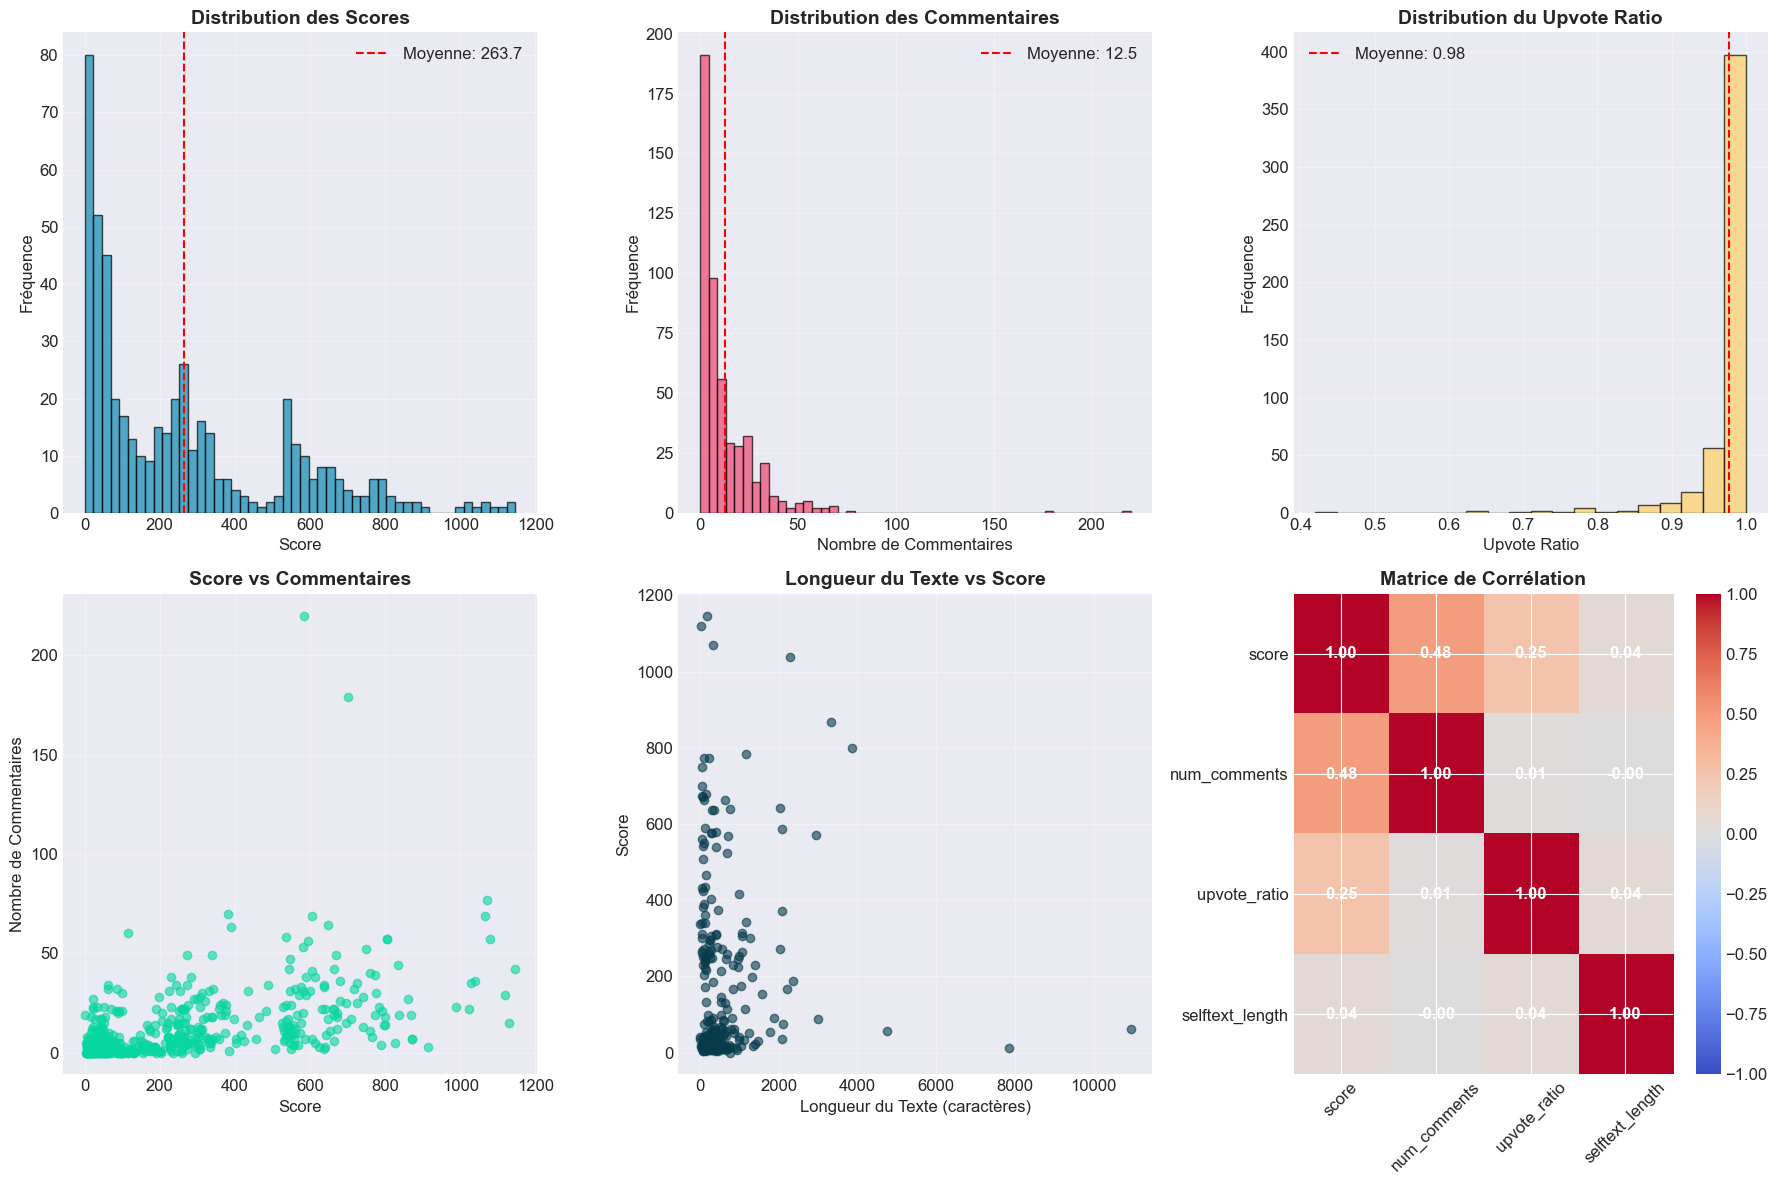

In [8]:
print("\n" + "="*60)
print("5. ANALYSE DES MÉTRIQUES D'ENGAGEMENT")
print("="*60)

# Statistiques descriptives complètes
print("Statistiques descriptives des principales métriques:")
stats_columns = ['score', 'num_comments', 'upvote_ratio', 'selftext_length']
print(df[stats_columns].describe().round(2))
print()

# Analyse des outliers
print("Identification des posts les plus engagés:")

# Top 10 par score
print("\nTop 10 posts par score:")
top_scores = df.nlargest(10, 'score')[['subreddit', 'title', 'score', 'num_comments', 'created_utc']]
print(top_scores.to_string(index=False))
print()

# Top 10 par commentaires
print("\nTop 10 posts par nombre de commentaires:")
top_comments = df.nlargest(10, 'num_comments')[['subreddit', 'title', 'score', 'num_comments', 'created_utc']]
print(top_comments.to_string(index=False))
print()

# Corrélations
print("Matrice de corrélation des métriques d'engagement:")
correlation_matrix = df[['score', 'num_comments', 'upvote_ratio', 'selftext_length']].corr()
print(correlation_matrix.round(3))
print()

# Visualisation des corrélations et distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Distribution des scores
axes[0, 0].hist(df['score'], bins=50, edgecolor='black', alpha=0.7, color='#118AB2')
axes[0, 0].set_title('Distribution des Scores', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Score')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].axvline(df['score'].mean(), color='red', linestyle='--', label=f"Moyenne: {df['score'].mean():.1f}")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Distribution des commentaires
axes[0, 1].hist(df['num_comments'], bins=50, edgecolor='black', alpha=0.7, color='#EF476F')
axes[0, 1].set_title('Distribution des Commentaires', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Nombre de Commentaires')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].axvline(df['num_comments'].mean(), color='red', linestyle='--', label=f"Moyenne: {df['num_comments'].mean():.1f}")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Distribution du upvote ratio
axes[0, 2].hist(df['upvote_ratio'], bins=20, edgecolor='black', alpha=0.7, color='#FFD166')
axes[0, 2].set_title('Distribution du Upvote Ratio', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Upvote Ratio')
axes[0, 2].set_ylabel('Fréquence')
axes[0, 2].axvline(df['upvote_ratio'].mean(), color='red', linestyle='--', label=f"Moyenne: {df['upvote_ratio'].mean():.2f}")
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Corrélation score vs commentaires
axes[1, 0].scatter(df['score'], df['num_comments'], alpha=0.6, color='#06D6A0')
axes[1, 0].set_title('Score vs Commentaires', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Score')
axes[1, 0].set_ylabel('Nombre de Commentaires')
axes[1, 0].grid(True, alpha=0.3)

# 5. Corrélation longueur vs engagement
axes[1, 1].scatter(df['selftext_length'], df['score'], alpha=0.6, color='#073B4C')
axes[1, 1].set_title('Longueur du Texte vs Score', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Longueur du Texte (caractères)')
axes[1, 1].set_ylabel('Score')
axes[1, 1].grid(True, alpha=0.3)

# 6. Heatmap des corrélations
im = axes[1, 2].imshow(correlation_matrix.values, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
axes[1, 2].set_title('Matrice de Corrélation', fontsize=14, fontweight='bold')
axes[1, 2].set_xticks(range(len(correlation_matrix.columns)))
axes[1, 2].set_yticks(range(len(correlation_matrix.columns)))
axes[1, 2].set_xticklabels(correlation_matrix.columns, rotation=45)
axes[1, 2].set_yticklabels(correlation_matrix.columns)

# Ajouter les valeurs dans la heatmap
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        text = axes[1, 2].text(j, i, f"{correlation_matrix.iloc[i, j]:.2f}",
                              ha="center", va="center", color="white", fontweight='bold')

plt.colorbar(im, ax=axes[1, 2])
plt.tight_layout()
plt.savefig('./data/cleaned/analyse_engagement.png', dpi=150, bbox_inches='tight')
plt.show()


6. ANALYSE DES ÉVÉNEMENTS ET PICS D'ACTIVITÉ
Top 10 jours avec le plus d'activité:
  2026-01-11: 18 posts
  2026-01-16: 15 posts
  2026-01-04: 14 posts
  2026-01-15: 14 posts
  2026-01-03: 13 posts
  2026-01-12: 13 posts
  2025-12-24: 12 posts
  2025-12-23: 11 posts
  2026-01-06: 11 posts
  2025-12-31: 10 posts

Activité autour des dates clés (+/- 7 jours):

  Début de l'opération Al-Aqsa (2023-10-07):
    - Posts dans la période: 0
    - Moyenne quotidienne: 0.0

  CIJ décision sur le génocide (2024-01-26):
    - Posts dans la période: 0
    - Moyenne quotidienne: 0.0

  Opération à Rafah (2024-05-06):
    - Posts dans la période: 1
    - Moyenne quotidienne: 0.1
    - Pic journalier: 1

  Élections US (2024-11-05):
    - Posts dans la période: 2
    - Moyenne quotidienne: 0.1
    - Pic journalier: 1


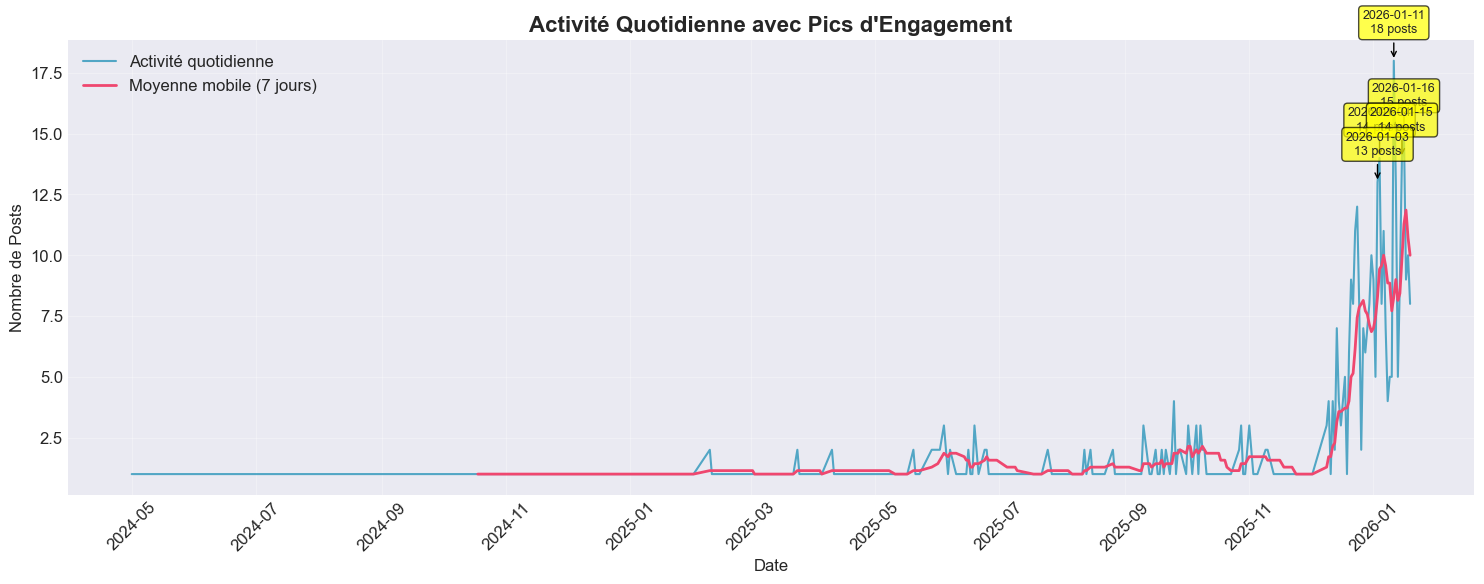

In [9]:
print("\n" + "="*60)
print("6. ANALYSE DES ÉVÉNEMENTS ET PICS D'ACTIVITÉ")
print("="*60)

# Identification des pics d'activité
daily_counts = df.groupby('created_date').size()
peak_days = daily_counts.nlargest(10)

print("Top 10 jours avec le plus d'activité:")
for date, count in peak_days.items():
    print(f"  {date}: {count} posts")

# Recherche d'événements spécifiques
# Dates clés du conflit israélo-palestinien (à adapter)
key_dates = {
    '2023-10-07': 'Début de l\'opération Al-Aqsa',
    '2024-01-26': 'CIJ décision sur le génocide',
    '2024-05-06': 'Opération à Rafah',
    '2024-11-05': 'Élections US'
}

print("\nActivité autour des dates clés (+/- 7 jours):")
for date_str, event in key_dates.items():
    try:
        event_date = pd.to_datetime(date_str).date()
        start_date = event_date - timedelta(days=7)
        end_date = event_date + timedelta(days=7)
        
        period_posts = df[(df['created_date'] >= start_date) & (df['created_date'] <= end_date)]
        total_posts = len(period_posts)
        avg_daily = total_posts / 15 if total_posts > 0 else 0
        
        print(f"\n  {event} ({date_str}):")
        print(f"    - Posts dans la période: {total_posts}")
        print(f"    - Moyenne quotidienne: {avg_daily:.1f}")
        
        if total_posts > 0:
            peak_in_period = period_posts.groupby('created_date').size().max()
            print(f"    - Pic journalier: {peak_in_period}")
    except:
        continue

# Visualisation des pics
fig, ax = plt.subplots(figsize=(15, 6))

# Courbe d'activité journalière
ax.plot(daily_counts.index, daily_counts.values, linewidth=1.5, color='#118AB2', alpha=0.7, label='Activité quotidienne')

# Ligne de tendance (moyenne mobile 7 jours)
rolling_avg = daily_counts.rolling(window=7).mean()
ax.plot(rolling_avg.index, rolling_avg.values, linewidth=2, color='#EF476F', label='Moyenne mobile (7 jours)')

# Marquer les pics
for date, count in peak_days.head(5).items():
    ax.annotate(f'{date}\n{count} posts', 
                xy=(date, count), 
                xytext=(0, 20),
                textcoords='offset points',
                ha='center',
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_title('Activité Quotidienne avec Pics d\'Engagement', fontsize=16, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Nombre de Posts')
ax.legend()
ax.grid(True, alpha=0.3)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('./data/cleaned/pics_activite.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print("\n" + "="*60)
print("RÉSUMÉ FINAL DE L'ANALYSE EXPLORATOIRE")
print("="*60)

# Création d'un rapport synthétique
report = {
    "Général": {
        "Total posts": len(df),
        "Période couverte": f"{df['created_utc'].min().date()} au {df['created_utc'].max().date()}",
        "Durée (jours)": (df['created_utc'].max() - df['created_utc'].min()).days,
    },
    "Distribution": {
        "BDS posts": len(bds_df),
        "BoycottIsrael posts": len(boycott_df),
        "Ratio BDS/BoycottIsrael": f"{len(bds_df)/len(boycott_df):.2f}",
        "Hot posts": len(df[df['post_type'] == 'hot']),
        "Top posts": len(df[df['post_type'] == 'top']),
    },
    "Auteurs": {
        "Auteurs uniques": unique_authors,
        "Ratio posts/auteur": f"{len(df)/unique_authors:.2f}",
        "Auteurs multi-subreddit": len(multi_subreddit_authors),
        "Top auteur": f"{author_counts.idxmax()} ({author_counts.max()} posts)",
    },
    "Engagement": {
        "Score moyen": f"{df['score'].mean():.1f}",
        "Score médian": f"{df['score'].median():.1f}",
        "Commentaires moyens": f"{df['num_comments'].mean():.1f}",
        "Upvote ratio moyen": f"{df['upvote_ratio'].mean():.3f}",
        "Corrélation score-commentaires": f"{df['score'].corr(df['num_comments']):.3f}",
    },
    "Contenu": {
        "Posts avec selftext vide": len(df[df['selftext'].str.strip() == '']),
        "Longueur moyenne du titre": f"{df['title'].str.len().mean():.1f}",
        "Longueur moyenne du selftext": f"{df['selftext_length'].mean():.1f}",
    }
}

# Affichage du rapport
for category, metrics in report.items():
    print(f"\n{category}:")
    for metric, value in metrics.items():
        print(f"  • {metric}: {value}")

# Export des données d'analyse
print("\n" + "="*60)
print("EXPORT DES RÉSULTATS")
print("="*60)

# Sauvegarde des données enrichies
df.to_csv('./data/cleaned/reddit_boycott_enriched.csv', index=False, encoding='utf-8')
print("✓ Données enrichies sauvegardées: reddit_boycott_enriched.csv")

# Export des statistiques clés
stats_summary = pd.DataFrame([
    ["Total Posts", len(df)],
    ["Période", f"{df['created_utc'].min().date()} - {df['created_utc'].max().date()}"],
    ["Auteurs Uniques", unique_authors],
    ["Score Moyen", f"{df['score'].mean():.1f}"],
    ["Commentaires Moyens", f"{df['num_comments'].mean():.1f}"],
    ["Posts BDS", len(bds_df)],
    ["Posts BoycottIsrael", len(boycott_df)],
    ["Corrélation Score-Comments", f"{df['score'].corr(df['num_comments']):.3f}"],
    ["Top Auteur", f"{author_counts.idxmax()} ({author_counts.max()} posts)"]
], columns=["Métrique", "Valeur"])

stats_summary.to_csv('./data/cleaned/stats_summary.csv', index=False)
print("✓ Résumé statistique sauvegardé: stats_summary.csv")

# Export des top auteurs
top_authors_df = author_counts.head(20).reset_index()
top_authors_df.columns = ['Auteur', 'Nombre de Posts']
top_authors_df.to_csv('./data/cleaned/top_authors.csv', index=False)
print("✓ Top auteurs sauvegardé: top_authors.csv")



RÉSUMÉ FINAL DE L'ANALYSE EXPLORATOIRE

Général:
  • Total posts: 501
  • Période couverte: 2024-05-01 au 2026-01-19
  • Durée (jours): 628

Distribution:
  • BDS posts: 275
  • BoycottIsrael posts: 226
  • Ratio BDS/BoycottIsrael: 1.22
  • Hot posts: 300
  • Top posts: 201

Auteurs:
  • Auteurs uniques: 255
  • Ratio posts/auteur: 1.96
  • Auteurs multi-subreddit: 19
  • Top auteur: Tr0jan___ (43 posts)

Engagement:
  • Score moyen: 263.7
  • Score médian: 187.0
  • Commentaires moyens: 12.5
  • Upvote ratio moyen: 0.978
  • Corrélation score-commentaires: 0.484

Contenu:
  • Posts avec selftext vide: 254
  • Longueur moyenne du titre: 66.1
  • Longueur moyenne du selftext: 611.8

EXPORT DES RÉSULTATS
✓ Données enrichies sauvegardées: reddit_boycott_enriched.csv
✓ Résumé statistique sauvegardé: stats_summary.csv
✓ Top auteurs sauvegardé: top_authors.csv
